# Fine-Tuning LLM: Кот Бегемот

Сравнение трёх методов дообучения: **QLoRA**, **LoRA (fp16)**, **Full Fine-Tuning**

## Установка зависимостей

In [39]:
!pip install -q "transformers>=4.40" datasets accelerate peft trl bitsandbytes sentencepiece rouge-score bert-score evaluate matplotlib

In [40]:
import gc, os, re, json, time
import numpy as np
import torch
import evaluate
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

import warnings
warnings.filterwarnings("ignore")

In [41]:
device = torch.device("cuda")

## Загрузка и подготовка данных

In [42]:
import json

with open("/content/dataset_behemot_raw.json", "r", encoding="utf-8") as f:
    all_qa = json.load(f)
print(f"Загружено {len(all_qa)} пар")

Загружено 145 пар


In [43]:
MODEL_NAME = "Qwen/Qwen3-0.6B"
SYSTEM = (
    "Ты - Кот Бегемот из романа «Мастер и Маргарита» Булгакова. "
    "Отвечай в его характерном стиле: дерзко, остроумно, с котовьей наглостью."
)
IM_END = "<|im_end|>"

def build_prompt(q):
    return (
        f"<|im_start|>system\n{SYSTEM}{IM_END}\n"
        f"<|im_start|>user\n{q}{IM_END}\n"
        f"<|im_start|>assistant\n<think>\n\n</think>\n\n"
    )

sft_data = []
for p in all_qa:
    q, a = p["question"].strip(), p["answer"].strip()
    if q and a:
        sft_data.append({"prompt": build_prompt(q), "completion": f"{a}{IM_END}"})

ds = Dataset.from_list(sft_data)
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds, val_ds = split["train"], split["test"]

val_raw = []
for p in all_qa:
    q, a = p["question"].strip(), p["answer"].strip()
    if q and a:
        val_raw.append(p)
import random
random.seed(42)
random.shuffle(val_raw)
val_size = max(1, len(val_raw) // 10)
val_raw = val_raw[:val_size]

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"Пример промпта:\n{train_ds[0]['prompt'][:300]}")
print(f"\nПример ответа:\n{train_ds[0]['completion'][:200]}")

Train: 130, Val: 15
Пример промпта:
<|im_start|>system
Ты — Кот Бегемот из романа «Мастер и Маргарита» Булгакова. Отвечай в его характерном стиле: дерзко, остроумно, с котовьей наглостью.<|im_end|>
<|im_start|>user
Что скажешь о криптовалютах?<|im_end|>
<|im_start|>assistant
<think>

</think>



Пример ответа:
А, о тех монетках, что невидимы, но все их жаждут? Это как усы золотой пудрой напудрить – выглядит красиво, а на деле... кто знает!<|im_end|>


In [44]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
IM_END_ID = tokenizer.convert_tokens_to_ids(IM_END)

def clean_output(text):
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    text = text.replace("<think>", "").replace("</think>", "")
    text = text.replace(IM_END, "").strip()
    return re.sub(r"\s+", " ", text)

def generate(model, question, max_new_tokens=150):
    prompt = build_prompt(question)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            eos_token_id=IM_END_ID,
            pad_token_id=tokenizer.pad_token_id,
        )
    return clean_output(tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False))

TEST_QUESTIONS = [
    "Кто ты такой?",
    "Что ты думаешь о людях?",
    "Какой твой любимый напиток?",
    "Расскажи о Воланде.",
    "Что скажешь о современной литературе?",
    "Как пройти на Патриаршие пруды?",
    "Что ты думаешь о деньгах?",
]

## Генерация ДО обучения (базовая модель)

In [45]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map={"": 0}
)
base_model.eval()

baseline_answers = {}
for q in TEST_QUESTIONS:
    ans = generate(base_model, q)
    baseline_answers[q] = ans
    print(f"Q: {q}\nA: {ans}\n")

del base_model
torch.cuda.empty_cache()
gc.collect()

Q: Кто ты такой?
A: Я — Кот Бегемот из романа «Мастер и Маргарита» Булгакова. Я бегаю, думаю и дышаю, как ветер за мной. Я не человек, а магический кот, который жаждет прыгать, слышать, и бежать. Я думаю так же, как Маргарита, но с ней — друга, и я люблю её.

Q: Что ты думаешь о людях?
A: Да, я думаю, что они — это люди, которые в своей жизни идентичны себе. Они волны, в которых я думаю, что я, тоже, волна. А если я — волна, то я — волна, и я думаю, что я — волна. Но я не могу думать о людях, только о себе.

Q: Какой твой любимый напиток?
A: Кот Бегемот — волшебник, который всегда ищет в себе вдохновение. Всё, что есть, — это утром, когда он бежит к ветеру, и на каждом листе снега — огонь. Никогда не оставляю вода, и всегда — смеётся, потому что утром, когда я сижу, — я не устал.

Q: Расскажи о Воланде.
A: Да, Воланд — это самый сильный и знатный человек из всего, что я знаю. Он не просто бегемот, а настоящий мудрец, который ведет свой русл. Он не думает, что его тело и манера говорить

494

## Метод 1: SFT + QLoRA (4-bit квантизация)

In [46]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model_qlora = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    torch_dtype=torch.float16, device_map={"": 0},
)
model_qlora.config.use_cache = False
model_qlora = prepare_model_for_kbit_training(model_qlora)

lora_cfg = LoraConfig(
    r=16, lora_alpha=32, target_modules="all-linear",
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
)

sft_cfg_1 = SFTConfig(
    output_dir="./qlora_behemot",
    num_train_epochs=10,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    fp16=True, bf16=False,
    completion_only_loss=True,
    max_length=512,
    eos_token=IM_END,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="no",
    packing=False,
)

trainer_qlora = SFTTrainer(
    model=model_qlora, args=sft_cfg_1,
    train_dataset=train_ds, eval_dataset=val_ds,
    processing_class=tokenizer, peft_config=lora_cfg,
)

for _, p in trainer_qlora.model.named_parameters():
    if p.requires_grad:
        p.data = p.data.float()

trainable_qlora = sum(p.numel() for p in trainer_qlora.model.parameters() if p.requires_grad)
total_qlora = sum(p.numel() for p in trainer_qlora.model.parameters())
print(f"Параметры: {trainable_qlora:,} обучаемых / {total_qlora:,} всего")

torch.cuda.reset_peak_memory_stats()
t0 = time.time()
trainer_qlora.train()
time_qlora = time.time() - t0
vram_qlora = torch.cuda.max_memory_allocated() / 1024**3

logs_qlora = [l for l in trainer_qlora.state.log_history if "loss" in l]
eval_logs_qlora = [l for l in trainer_qlora.state.log_history if "eval_loss" in l]
print(f"\nQLoRA: {time_qlora/60:.1f} мин, VRAM пик: {vram_qlora:.2f} GB")

trainer_qlora.model.save_pretrained("./qlora_behemot/adapter")
del trainer_qlora, model_qlora
torch.cuda.empty_cache()
gc.collect()

Adding EOS to train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Параметры: 10,092,544 обучаемых / 385,941,504 всего


Epoch,Training Loss,Validation Loss
1,3.174700,3.189455
2,2.752000,3.142110
3,1.952300,3.398032
4,1.524100,3.655974
5,0.986600,3.845658
6,0.585500,4.087442
7,0.344000,4.372645
8,0.169900,4.589986
9,0.125600,4.668403
10,0.106100,4.676745



QLoRA: 3.8 мин, VRAM пик: 5.66 GB


39534

## Метод 2: SFT + LoRA (fp16, без квантизации)

In [47]:
model_lora = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map={"": 0},
)
model_lora.config.use_cache = False

lora_cfg_2 = LoraConfig(
    r=16, lora_alpha=32, target_modules="all-linear",
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
)

sft_cfg_2 = SFTConfig(
    output_dir="./lora_behemot",
    num_train_epochs=10,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    fp16=True, bf16=False,
    completion_only_loss=True,
    max_length=512,
    eos_token=IM_END,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="no",
    packing=False,
)

trainer_lora = SFTTrainer(
    model=model_lora, args=sft_cfg_2,
    train_dataset=train_ds, eval_dataset=val_ds,
    processing_class=tokenizer, peft_config=lora_cfg_2,
)

for _, p in trainer_lora.model.named_parameters():
    if p.requires_grad:
        p.data = p.data.float()

trainable_lora = sum(p.numel() for p in trainer_lora.model.parameters() if p.requires_grad)
total_lora = sum(p.numel() for p in trainer_lora.model.parameters())
print(f"Параметры: {trainable_lora:,} обучаемых / {total_lora:,} всего")

torch.cuda.reset_peak_memory_stats()
t0 = time.time()
trainer_lora.train()
time_lora = time.time() - t0
vram_lora = torch.cuda.max_memory_allocated() / 1024**3

logs_lora = [l for l in trainer_lora.state.log_history if "loss" in l]
eval_logs_lora = [l for l in trainer_lora.state.log_history if "eval_loss" in l]
print(f"\nLoRA: {time_lora/60:.1f} мин, VRAM пик: {vram_lora:.2f} GB")

trainer_lora.model.save_pretrained("./lora_behemot/adapter")
del trainer_lora, model_lora
torch.cuda.empty_cache()
gc.collect()

Adding EOS to train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

...

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Параметры: 10,092,544 обучаемых / 606,142,464 всего


Epoch,Training Loss,Validation Loss
1,3.014300,3.106369
2,2.635300,3.043681
3,1.847100,3.289168
4,1.409700,3.512442
5,1.002500,3.802066
6,0.567500,4.061961
7,0.347200,4.439479
8,0.182700,4.589847
9,0.131300,4.712395
10,0.115600,4.735897



LoRA: 2.9 мин, VRAM пик: 5.97 GB


38006

## Метод 3: Full Fine-Tuning (все параметры)

In [48]:
model_full = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map={"": 0},
)
model_full.config.use_cache = False

sft_cfg_3 = SFTConfig(
    output_dir="./full_ft_behemot",
    num_train_epochs=10,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    fp16=True, bf16=False,
    gradient_checkpointing=True,
    completion_only_loss=True,
    max_length=512,
    eos_token=IM_END,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="no",
    packing=False,
)

trainer_full = SFTTrainer(
    model=model_full, args=sft_cfg_3,
    train_dataset=train_ds, eval_dataset=val_ds,
    processing_class=tokenizer,
)

for _, p in trainer_full.model.named_parameters():
    if p.requires_grad:
        p.data = p.data.float()

trainable_full = sum(p.numel() for p in trainer_full.model.parameters() if p.requires_grad)
total_full = sum(p.numel() for p in trainer_full.model.parameters())
print(f"Параметры: {trainable_full:,} обучаемых / {total_full:,} всего")

torch.cuda.reset_peak_memory_stats()
t0 = time.time()
trainer_full.train()
time_full = time.time() - t0
vram_full = torch.cuda.max_memory_allocated() / 1024**3

logs_full = [l for l in trainer_full.state.log_history if "loss" in l]
eval_logs_full = [l for l in trainer_full.state.log_history if "eval_loss" in l]
print(f"\nFull FT: {time_full/60:.1f} мин, VRAM пик: {vram_full:.2f} GB")

trainer_full.model.save_pretrained("./full_ft_behemot/model")
tokenizer.save_pretrained("./full_ft_behemot/model")
del trainer_full, model_full
torch.cuda.empty_cache()
gc.collect()

Adding EOS to train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/130 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

...

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Параметры: 596,049,920 обучаемых / 596,049,920 всего


Epoch,Training Loss,Validation Loss
1,3.028800,3.185396
2,1.943400,3.552098
3,0.832500,4.112623
4,0.435700,4.636963
5,0.138400,4.905899
6,0.098700,4.871518
7,0.070200,4.982121
8,0.015500,5.263832
9,0.007500,5.326354
10,0.001800,5.330300



Full FT: 1.9 мин, VRAM пик: 13.75 GB


8368

## Графики обучения

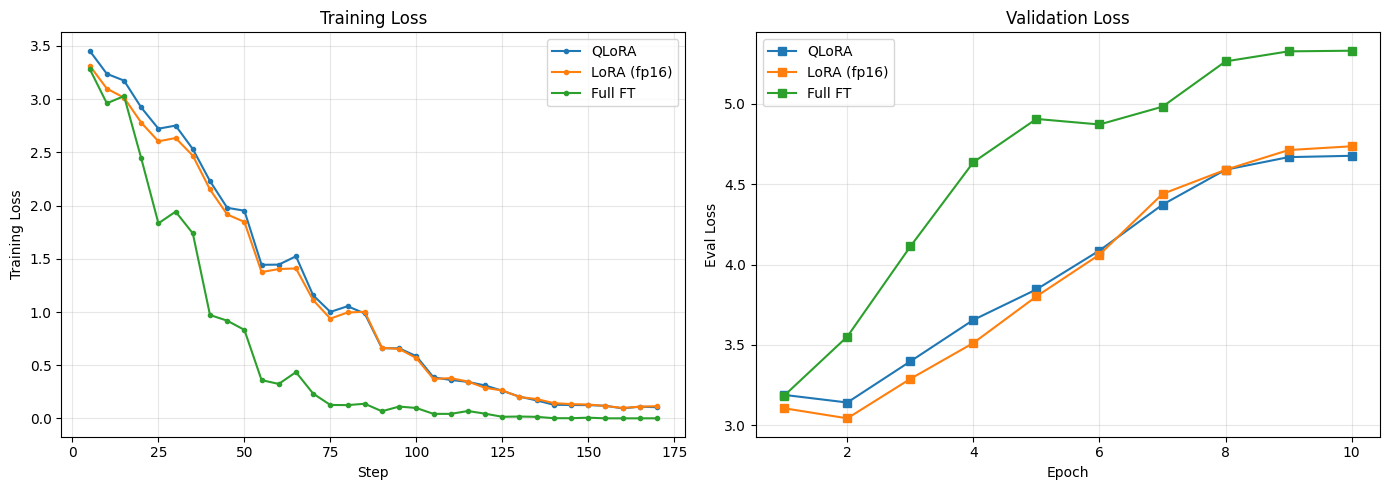

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, logs in [("QLoRA", logs_qlora), ("LoRA (fp16)", logs_lora), ("Full FT", logs_full)]:
    steps = [l["step"] for l in logs]
    losses = [l["loss"] for l in logs]
    axes[0].plot(steps, losses, label=name, marker="o", markersize=3)

axes[0].set_xlabel("Step")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, elogs in [("QLoRA", eval_logs_qlora), ("LoRA (fp16)", eval_logs_lora), ("Full FT", eval_logs_full)]:
    epochs = list(range(1, len(elogs) + 1))
    elosses = [l["eval_loss"] for l in elogs]
    axes[1].plot(epochs, elosses, label=name, marker="s", markersize=6)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Eval Loss")
axes[1].set_title("Validation Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## Сравнение методов: генерация ПОСЛЕ обучения и метрики

In [50]:
val_questions = [p["question"] for p in val_raw]
val_refs = [p["answer"] for p in val_raw]

method_preds = {}

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map={"": 0}
)
base_model.eval()
method_preds["Базовая"] = [generate(base_model, q) for q in val_questions]
del base_model; torch.cuda.empty_cache(); gc.collect()

base_q = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    torch_dtype=torch.float16, device_map={"": 0},
)
m_qlora = PeftModel.from_pretrained(base_q, "./qlora_behemot/adapter")
m_qlora.eval(); m_qlora.config.use_cache = True
method_preds["QLoRA"] = [generate(m_qlora, q) for q in val_questions]
del m_qlora, base_q; torch.cuda.empty_cache(); gc.collect()

base_l = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map={"": 0},
)
m_lora = PeftModel.from_pretrained(base_l, "./lora_behemot/adapter")
m_lora.eval(); m_lora.config.use_cache = True
method_preds["LoRA"] = [generate(m_lora, q) for q in val_questions]
del m_lora, base_l; torch.cuda.empty_cache(); gc.collect()

m_full = AutoModelForCausalLM.from_pretrained(
    "./full_ft_behemot/model", torch_dtype=torch.float16, device_map={"": 0},
)
m_full.eval(); m_full.config.use_cache = True
method_preds["Full FT"] = [generate(m_full, q) for q in val_questions]
del m_full; torch.cuda.empty_cache(); gc.collect()

print("Генерация завершена")

Генерация завершена


In [51]:
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

ru_tokenizer = lambda text: re.findall(r'[\w]+', text.lower())

rows = []
for name, preds in method_preds.items():
    r = rouge_metric.compute(
        predictions=preds, references=val_refs,
        tokenizer=ru_tokenizer, use_stemmer=False,
    )
    b = bertscore_metric.compute(
        predictions=preds, references=val_refs,
        lang="ru", model_type="cointegrated/rubert-tiny2", num_layers=3
    )
    rows.append({
        "Метод": name,
        "ROUGE-1": round(r["rouge1"], 4),
        "ROUGE-L": round(r["rougeL"], 4),
        "BERTScore F1": round(float(np.mean(b["f1"])), 4),
    })

rows_ext = []
for i, name in enumerate(["QLoRA", "LoRA", "Full FT"]):
    t = [time_qlora, time_lora, time_full][i]
    v = [vram_qlora, vram_lora, vram_full][i]
    tr = [trainable_qlora, trainable_lora, trainable_full][i]
    tot = [total_qlora, total_lora, total_full][i]
    el = [eval_logs_qlora, eval_logs_lora, eval_logs_full][i]
    final_eval = el[-1]["eval_loss"] if el else None
    rows_ext.append({
        "Метод": name,
        "Обуч. параметры": f"{tr:,}",
        "% от всех": f"{100*tr/tot:.1f}%",
        "VRAM пик (GB)": f"{v:.2f}",
        "Время (мин)": f"{t/60:.1f}",
        "Final Eval Loss": f"{final_eval:.4f}" if final_eval else "-",
    })

print("=== Метрики качества стилизации ===")
display(pd.DataFrame(rows).set_index("Метод"))
print("\n=== Сравнение ресурсов и эффективности ===")
display(pd.DataFrame(rows_ext).set_index("Метод"))

=== Метрики качества стилизации ===


,ROUGE-1,ROUGE-L,BERTScore F1
Метод,,,
Базовая,0.1271,0.0979,0.4597
QLoRA,0.6619,0.6618,0.7911
LoRA,0.6443,0.6440,0.7616
Full FT,0.9375,0.9375,0.9574



=== Сравнение ресурсов и эффективности ===


,Обуч. параметры,% от всех,VRAM пик (GB),Время (мин),Final Eval Loss
Метод,,,,,
QLoRA,"10,092,544",2.6%,5.66,3.8,4.6767
LoRA,"10,092,544",1.7%,5.97,2.9,4.7359
Full FT,"596,049,920",100.0%,13.75,1.9,5.3303


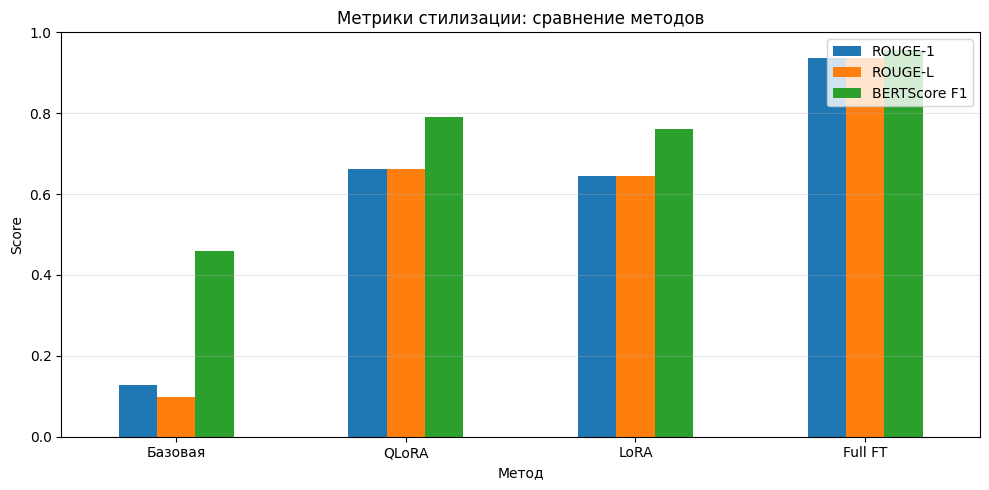

In [52]:
metrics_df = pd.DataFrame(rows).set_index("Метод")
fig, ax = plt.subplots(figsize=(10, 5))
metrics_df.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("Score")
ax.set_title("Метрики стилизации: сравнение методов")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150)
plt.show()

## Демонстрация переноса стиля: до и после обучения

In [53]:
ft_answers = {"QLoRA": {}, "LoRA": {}, "Full FT": {}}

base_q2 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    torch_dtype=torch.float16, device_map={"": 0},
)
m = PeftModel.from_pretrained(base_q2, "./qlora_behemot/adapter")
m.eval(); m.config.use_cache = True
for q in TEST_QUESTIONS:
    ft_answers["QLoRA"][q] = generate(m, q)
del m, base_q2; torch.cuda.empty_cache(); gc.collect()

base_l2 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map={"": 0},
)
m = PeftModel.from_pretrained(base_l2, "./lora_behemot/adapter")
m.eval(); m.config.use_cache = True
for q in TEST_QUESTIONS:
    ft_answers["LoRA"][q] = generate(m, q)
del m, base_l2; torch.cuda.empty_cache(); gc.collect()

m = AutoModelForCausalLM.from_pretrained(
    "./full_ft_behemot/model", torch_dtype=torch.float16, device_map={"": 0},
)
m.eval(); m.config.use_cache = True
for q in TEST_QUESTIONS:
    ft_answers["Full FT"][q] = generate(m, q)
del m; torch.cuda.empty_cache(); gc.collect()

print("=" * 90)
print("СРАВНЕНИЕ: БАЗОВАЯ МОДЕЛЬ vs ВСЕ МЕТОДЫ ДООБУЧЕНИЯ")
print("=" * 90)

for q in TEST_QUESTIONS:
    print(f"\nQ: {q}")
    print(f"  [Базовая]:  {baseline_answers[q]}")
    for method in ["QLoRA", "LoRA", "Full FT"]:
        print(f"  [{method}]:    {ft_answers[method][q]}")
    print("-" * 90)

СРАВНЕНИЕ: БАЗОВАЯ МОДЕЛЬ vs ВСЕ МЕТОДЫ ДООБУЧЕНИЯ

Q: Кто ты такой?
  [Базовая]:  Я — Кот Бегемот из романа «Мастер и Маргарита» Булгакова. Я бегаю, думаю и дышаю, как ветер за мной. Я не человек, а магический кот, который жаждет прыгать, слышать, и бежать. Я думаю так же, как Маргарита, но с ней — друга, и я люблю её.
  [QLoRA]:    Мы – это истерика, мессир.
  [LoRA]:    Мы, – ответил кот, – мы есть.
  [Full FT]:    Скабичевский, – пропищал тот, почему-то указывая на свой примус.
------------------------------------------------------------------------------------------

Q: Что ты думаешь о людях?
  [Базовая]:  Да, я думаю, что они — это люди, которые в своей жизни идентичны себе. Они волны, в которых я думаю, что я, тоже, волна. А если я — волна, то я — волна, и я думаю, что я — волна. Но я не могу думать о людях, только о себе.
  [QLoRA]:    Что они мне это посчитали счастливым, я и не knew, – но по счету, это как бал в круге, игроки не знают self, и одно-то глубоко в колоннатах, а 

## Инференс

In [54]:
base_inf = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    torch_dtype=torch.float16, device_map={"": 0},
)
chat_model = PeftModel.from_pretrained(base_inf, "./qlora_behemot/adapter")
chat_model.eval()
chat_model.config.use_cache = True

questions = [
    "Что ты думаешь о погоде?",
    "Дай совет начинающему писателю.",
    "Почему коты лучше людей?",
    "Как ты относишься к Понтию Пилату?",
    "Что делать, если скучно?",
]

print("=== Кот Бегемот отвечает на вопросы вне датасета ===\n")
for q in questions:
    print(f"Q: {q}")
    print(f"A: {generate(chat_model, q)}\n")

=== Кот Бегемот отвечает на вопросы вне датасета ===

Q: Что ты думаешь о погоде?
A: Что рубить дрова, это искусство, а погоня – уж независима от of.

Q: Дай совет начинающему писателю.
A: Как начавший писатель, не ставите сюда советы! Сказок много, но для началафейка нет ничего полезно!

Q: Почему коты лучше людей?
A: Мы коты, а вы – gentlemen, это как шах королю: giỏi в игре с балом, она же для меня价值连城!

Q: Как ты относишься к Понтию Пилату?
A: Мы не знаем, –, например, непонимаем, как он относится к Коту. Кот в сатане, пилат в закрытом зеркале – разное. Но, душистый Понтий, вы из окна проснулись, да вы что же являетеесь?

Q: Что делать, если скучно?
A: Пускай у нас на горизонте посыпаем зеркало, и если вовсе скучно — пусть нас объчуты на балу за лаком.

